In [ ]:
import pandas as pd
df=pd.read_csv("crime_data.csv")
df

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     object 
 1   Murder      50 non-null     float64
 2   Assault     50 non-null     int64  
 3   UrbanPop    50 non-null     int64  
 4   Rape        50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [ ]:
df = df.drop(columns=df.columns[df.columns == 'Unnamed: 0'])

In [ ]:
X=df.iloc[:,0:]
X

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6
5,7.9,204,78,38.7
6,3.3,110,77,11.1
7,5.9,238,72,15.8
8,15.4,335,80,31.9
9,17.4,211,60,25.8


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
linkage_matrix = linkage(df, method='ward')

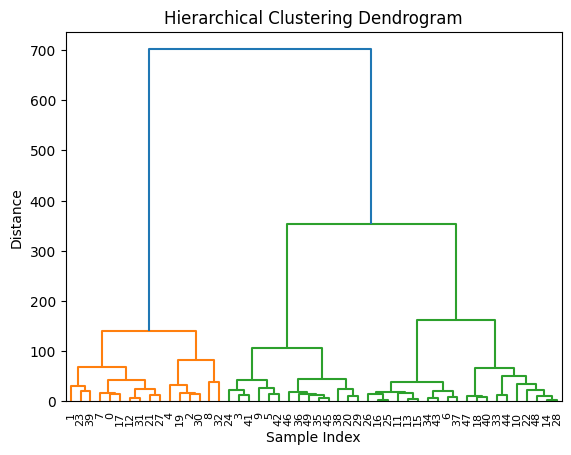

In [ ]:
# Plot the dendrogram
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, n_init=30, random_state=0)
kmeans.fit(X)
Y = kmeans.predict(X)
cluster_counts = pd.DataFrame(Y, columns=['Cluster']).value_counts().reset_index(name='Count')
print(cluster_counts)
print("Inertia:", kmeans.inertia_)

   Cluster  Count
0        1     14
1        3     12
2        0     10
3        4     10
4        2      4
Inertia: 24417.02352380952


In [ ]:
# Elbow Method
inertia = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(X)
    inertia.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

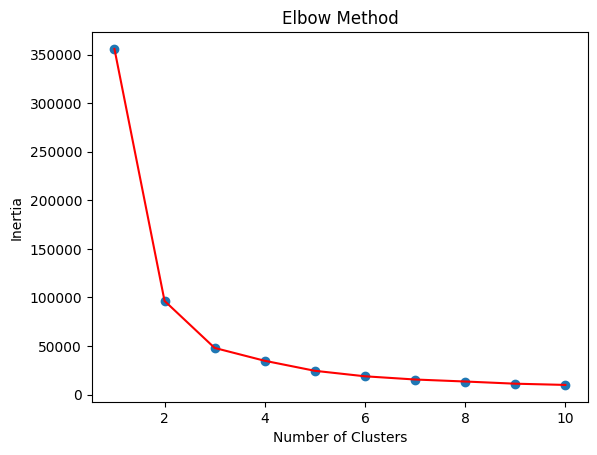

In [ ]:

# Plotting the Elbow Method
plt.scatter(range(1, 11), inertia)
plt.plot(range(1, 11), inertia, color='red')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X = SS.fit_transform(X)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans

# DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(SS_X)

# Check the number of points in each cluster (excluding noise points)
cl = pd.DataFrame(dbscan_labels, columns=['cluster'])
print(cl['cluster'].value_counts())


 0    49
-1     1
Name: cluster, dtype: int64


In [ ]:
# Filter out noise points
clustered_data = pd.concat([df, cl], axis=1)
final_data = clustered_data[clustered_data['cluster'] != -1]

In [ ]:
# KMeans clustering on the resulting data from DBSCAN
kmeans = KMeans(n_clusters=5, n_init=30, random_state=0)
kmeans_labels = kmeans.fit_predict(final_data)


In [ ]:
# Check the number of points in each KMeans cluster
kmeans_cluster_counts = pd.DataFrame(kmeans_labels, columns=['cluster']).value_counts().reset_index(name='Count')
print(kmeans_cluster_counts)

   cluster  Count
0        3     13
1        0     10
2        2     10
3        1      9
4        4      7


In [ ]:
# Elbow Method for KMeans
inertia = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(final_data.drop('cluster', axis=1))  # Drop the 'cluster' column before fitting
    inertia.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

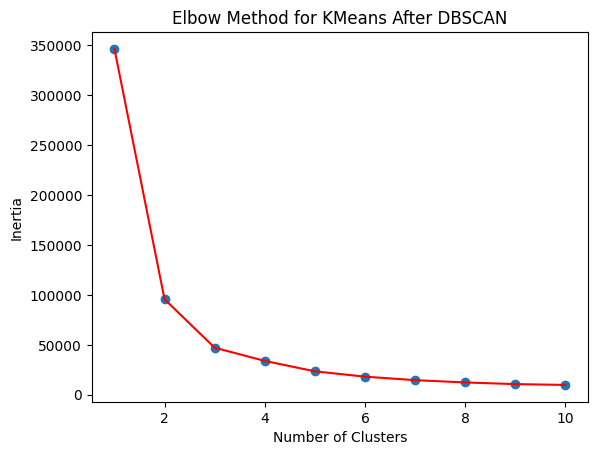

In [ ]:
# Plotting the Elbow Method
plt.scatter(range(1, 11), inertia)
plt.plot(range(1, 11), inertia, color='red')
plt.title('Elbow Method for KMeans After DBSCAN')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()